In [131]:
import pandas as pd
import numpy as np

In [132]:
from google.colab import files
uploaded = files.upload()
loyalty=pd.read_csv('Customer Loyalty History (1).csv')


Saving Customer Loyalty History (1).csv to Customer Loyalty History (1) (3).csv


In [133]:
from google.colab import files
uploaded = files.upload()
activity=pd.read_csv('Customer Flight Activity.csv')

Saving Customer Flight Activity.csv to Customer Flight Activity (3).csv


In [134]:
from google.colab import files
uploaded = files.upload()
calendar=pd.read_csv('Calendar.csv')

Saving Calendar.csv to Calendar (3).csv


In [135]:
print(loyalty["Salary"].isna().sum())

4238


In [136]:
#--------------------DATA CLEANING----------------------------
"""The dataset customer loyalty history have some negative values
in the salary column which is clearly a data entry mistake,
so we the negative values were replaced with Nan."""
neg_mask = loyalty["Salary"] < 0
print(f"\nNegative salaries found : {neg_mask.sum()}")

loyalty.loc[neg_mask, "Salary"] = np.nan




Negative salaries found : 20


In [137]:
 #DUPLICATES
dupe_count = loyalty["Loyalty Number"].duplicated().sum()
print(f"Duplicate Loyalty IDs: {dupe_count}")
loyalty = loyalty.drop_duplicates(subset="Loyalty Number", keep="first")

Duplicate Loyalty IDs: 0


In [138]:
'''we have sorted customers on the basis of education,and found total null values'''
print(loyalty[loyalty["Salary"].isna()]["Education"].value_counts().to_string())

Education
College                 4238
Bachelor                  19
High School or Below       1


In [139]:
"""We have observed in the above cell that there are total 4258 columns that have
NaN values in salary column,so the null values are been replaced with median,we have
grouped the customers by education  and marital status .
Since people with similar spending capacity might have similar salaries.
Household income and financial behaviour differ meaningfully between single, married, and divorced individuals.
Married members often have dual incomes or different spending patterns"""

loyalty["Salary"] = (
    loyalty
    .groupby(["Education", "Marital Status"])["Salary"]
    .transform(lambda x: x.fillna(x.median()))
)
loyalty["Salary"] = loyalty["Salary"].fillna(loyalty["Salary"].median())
print(f"NaNs after imputation : {loyalty['Salary'].isna().sum()}")

NaNs after imputation : 0


In [140]:
#-----------------Calendar----------------------------------
""""1. Date Formats: All four date columns are currently sitting as plain text strings.
    We need to convert them into real date objects so python actually understands
    timelines and chronological order.

2. Clashing Timelines: The calendar table tracks data day-by-day (2,557 rows),
    but our customer activity data is grouped month-by-month. To bridge this gap,
    we'll distill the calendar down into a quick "monthly lookup cheat sheet".
    This lets us easily inject "Quarter" and "Season" tags straight into the activity logs."""


for col in calendar.columns:
    calendar[col] = pd.to_datetime(calendar[col])
print(f"  All date columns parsed to datetime.")

# Month-level lookup: one row per (Year, Month)
cal_monthly = (
    calendar
    .assign(
        Year    = calendar["Date"].dt.year,
        Month   = calendar["Date"].dt.month,
        Quarter = calendar["Date"].dt.quarter,
        Season  = calendar["Date"].dt.month.map({
            1:"Winter", 2:"Winter", 3:"Spring",  4:"Spring",
            5:"Spring",  6:"Summer", 7:"Summer",  8:"Summer",
            9:"Autumn", 10:"Autumn",11:"Autumn", 12:"Winter",
        }),
    )
    .groupby(["Year","Month"], as_index=False)
    .agg(Quarter=("Quarter","first"), Season=("Season","first"))
)
print(f"  Monthly lookup built : {cal_monthly.shape[0]} rows "
      f"({cal_monthly['Year'].min()}–{cal_monthly['Year'].max()})")


  All date columns parsed to datetime.
  Monthly lookup built : 84 rows (2012–2018)


In [141]:

"""In the data we see that some members have their cancellation date is  same month
 and year as their enrollment month and year,which is not operationally possible
 so we converted them as active members.
 """


# Step 1: Creating a continuous timeline in months to compare the enrollment and cancellation date
loyalty["enrollment_ym"] = loyalty["Enrollment Year"] * 12 + loyalty["Enrollment Month"]
loyalty["cancellation_ym"] = (
    loyalty["Cancellation Year"].fillna(0) * 12 +
    loyalty["Cancellation Month"].fillna(0)
)

# Step 2: Mask rows where cancellation occurs before to or during enrollment
bad_cancel = (
    loyalty["Cancellation Year"].notna() &
    (loyalty["cancellation_ym"] <= loyalty["enrollment_ym"])
)


print(f"\nBad cancellation dates : {bad_cancel.sum()}")
print(loyalty.loc[bad_cancel, ["Loyalty Number", "Enrollment Year", "Enrollment Month",
                                "Cancellation Year", "Cancellation Month"]]
      .to_string(index=False))

# Step 3: Nullify the  cancellation dates & drop temporary timeline columns
loyalty.loc[bad_cancel, ["Cancellation Year", "Cancellation Month"]] = np.nan
loyalty.drop(columns=["enrollment_ym", "cancellation_ym"], inplace=True)


Bad cancellation dates : 11
 Loyalty Number  Enrollment Year  Enrollment Month  Cancellation Year  Cancellation Month
         607266             2016                 3             2016.0                 3.0
         939593             2013                 9             2013.0                 9.0
         140042             2014                 8             2014.0                 8.0
         488724             2013                 1             2013.0                 1.0
         160779             2017                12             2017.0                12.0
         472283             2014                 4             2014.0                 4.0
         239221             2014                 5             2014.0                 5.0
         896685             2016                12             2016.0                12.0
         304528             2018                 8             2018.0                 8.0
         871455             2017                 6             2017.0  

In [142]:
""" Flag CLV Outliers
Found: 168 members above 99th percentile (CLV > $35,929).
These are real high-value customers.
"""
clv_p99 = loyalty["CLV"].quantile(0.99)
loyalty["clv_outlier"] = (loyalty["CLV"] > clv_p99).astype(int)
print(f" CLV 99th percentile= ${clv_p99:,.2f}")
print(f" Outliers flagged : {loyalty['clv_outlier'].sum()}")

 CLV 99th percentile= $35,928.64
 Outliers flagged : 168


In [143]:
""" Ordinal Encoding (from Data Dictionary)
 Data dictionary explicitly states: Star < Nova < Aurora  and
  High School or Below < College < Bachelor < Master < Doctor"""
LOYALTY_ORDER   = ["Star","Nova","Aurora"]
EDUCATION_ORDER = ["High School or Below","College","Bachelor","Master","Doctor"]

loyalty["loyalty_tier"] = (
    pd.Categorical(loyalty["Loyalty Card"], categories=LOYALTY_ORDER, ordered=True)
    .codes + 1        # Star=1, Nova=2, Aurora=3
)
loyalty["education_level"] = (
    pd.Categorical(loyalty["Education"], categories=EDUCATION_ORDER, ordered=True)
    .codes + 1        # High School=1, College=2, Bachelor=3, Master=4, Doctor=5
)
print(f"\nloyalty_tier distribution:\n{loyalty['loyalty_tier'].value_counts().sort_index().to_string()}")
print(f"\n education_level distribution:\n{loyalty['education_level'].value_counts().sort_index().to_string()}")




loyalty_tier distribution:
loyalty_tier
1    7637
2    5671
3    3429

 education_level distribution:
education_level
1      782
2     4238
3    10475
4      508
5      734


In [144]:
for col in ["Total Flights", "Distance", "Points Accumulated", "Points Redeemed"]:
    neg = (activity[col] < 0).sum()
    if neg > 0:
        print(f"Negative values in '{col}': {neg} → clipped to 0")
        activity[col] = activity[col].clip(lower=0)

In [145]:
loyalty["years_enrolled"] = (2017 - loyalty["Enrollment Year"]).clip(lower=0)
loyalty["enrolled_post_window"] = (loyalty["Enrollment Year"] >= 2018).astype(int)
print(f"Post-window enrollees flagged: {loyalty['enrolled_post_window'].sum()}")

Post-window enrollees flagged: 3010


In [146]:

""" this  raw data contains two types of duplicates for the same customer within
the same month:
Type A (Pure Duplicate Rows): The exact same row got recorded twice by accident
. If we just sum these up, you double the real numbers, which ruins the data.
Type B (Split Transactions): The customer booked multiple independent flights
in the same month (e.g: a flight on Week 1 and a flight on Week 3), causing the system
to generate separate rows for each booking.So we  Removes exact system row duplicates
first, then aggregates split multi-bookings.
"""
METRIC_COLS = [
    "Total Flights", "Distance", "Points Accumulated",
    "Points Redeemed", "Dollar Cost Points Redeemed"
]
KEY_COLS = ["Loyalty Number", "Year", "Month"]

before_rows = len(activity)

activity = activity.drop_duplicates()  # Fixes Type A: Drops pure entry copies safely
activity = activity.groupby(KEY_COLS, as_index=False)[METRIC_COLS].sum()  # Fixes Type B

after_rows = len(activity)
print(f"Rows reduced from {before_rows} to {after_rows} (Dropped: {before_rows - after_rows})")

Rows reduced from 392936 to 389065 (Dropped: 3871)


In [147]:
"""Join Calendar ,add Quarter and Season
 Activity covers 2017–2018 (24 month combos). All 24 confirmed present in cal_monthly, zero orphan joins expected."""
activity = activity.merge(cal_monthly, on=["Year","Month"], how="left")
missing = activity["Quarter"].isna().sum()
print(f"\n Calendar joined. Rows with missing Quarter : {missing}")
print(f"       Seasons in data : {sorted(activity['Season'].unique())}")


 Calendar joined. Rows with missing Quarter : 0
       Seasons in data : ['Autumn', 'Spring', 'Summer', 'Winter']


In [148]:
"""Generate Standardized Timestamps
 Context: Converts distinct integer date pillars into a uniform timestamp tracking index."""
activity["date"] = pd.to_datetime(activity[["Year", "Month"]].assign(Day=1))
print(f"\n Datetime Parsing: Complete (Range: {activity['date'].min().date()} to {activity['date'].max().date()})")


 Datetime Parsing: Complete (Range: 2017-01-01 to 2018-12-01)


In [149]:
"""Flag Window-Exceeded Redemptions
 Context: Tracks legacy members who redeemed points earned prior to the 2017 dataset window.
 Action: Uses high-performance vectorized transforms to tag window variances."""
grouped_members = activity.groupby("Loyalty Number")
window_accumulated = grouped_members["Points Accumulated"].transform("sum")
window_redeemed = grouped_members["Points Redeemed"].transform("sum")

# Apply binary flag directly via conditional evaluation
activity["redemption_exceeds_window"] = (window_redeemed > window_accumulated).astype(int)

flagged_count = activity.drop_duplicates("Loyalty Number")["redemption_exceeds_window"].sum()
print(f"\n   Legacy Account Isolation:")
print(f" Flagged {flagged_count} members with active historical balances used within this window.")

# Finalize Cleaned Output File
activity_clean = activity.copy()
print(f"\nFinal Cleaned Activity Matrix Shape: {activity_clean.shape}")


   Legacy Account Isolation:
 Flagged 11 members with active historical balances used within this window.

Final Cleaned Activity Matrix Shape: (389065, 12)


In [150]:
"""this is to show the number of active members after the issue with cancellation
dates are resolved
in the output:
False represents active members
True represents not active members"""
loyalty["not_active_members"] = loyalty["Cancellation Year"].notna()
print("\nBreakdown of 'active_members':")
print(loyalty["not_active_members"].value_counts().to_string())


Breakdown of 'active_members':
not_active_members
False    14681
True      2056


In [151]:
# ============================================================
# CHURN LABEL CONSTRUCTION
# ============================================================

# BUSINESS CONTEXT:
# -----------------
# We are standing at December 2017, looking forward.
# The question we are answering is:
# "Which members are likely to disengage in the coming year?"
#
# Features are built entirely from 2017 and earlier data.
# Labels are derived from 2017–2018 outcomes.
# 2018 activity data is used ONLY for label construction,
# never as a feature — this prevents data leakage.
#
# WHAT CHURN MEANS HERE:
# ----------------------
# Churn is not just formal cancellation. A member can stop
# flying entirely while remaining enrolled. We capture this
# through three signals that together paint the full picture
# of disengagement in this dataset.
#
# WHY 7.8% IS THE RIGHT CHURN RATE:
# ----------------------------------
# The program was growing in 2018 (12,439 active in 2017
# vs 14,614 active in 2018), so mass silent disengagement
# was not happening. 7.8% reflects a real but contained
# churn problem — concentrated in formal cancellations
# with a meaningful layer of silent high-value losses.
#
# THREE SIGNALS:
# --------------
# Signal 1 — FORMAL CHURN
#   Cancelled membership in 2017 or 2018.
#   This is ground truth — unambiguous and clean.
#   We include 2017 cancellations because we have full
#   visibility of that year and they represent real losses.
#   Pre-2017 cancellations are excluded — those members
#   already left before our prediction window opens.
#
# Signal 2 — SILENT DISENGAGEMENT
#   Enrolled before 2017 + zero flights in all of 2017
#   + CLV above the overall median + never cancelled.
#   The CLV filter (> 5,780) is critical — it removes
#   2012 never-actives who signed up at program launch
#   and never engaged. High CLV on a zero-flight member
#   means they were genuinely valuable and have gone quiet.
#   We have no pre-2017 activity data, so enrollment year
#   is our best proxy for prior engagement history.
#
# Signal 3 — LATE STAGE RISK
#   Flew in 2017 but completely silent in 2018 + no cancel.
#   These members were active right up to our prediction
#   window and then vanished. Small in number (33) but
#   the clearest possible behavioral signal of departure.


# ============================================================
# STEP 1 — BUILD ACTIVITY SETS
# ============================================================

# Members who flew at any point in 2017
# Used as "was active" proof for Signals 2 and 3
active_in_2017 = set(
    activity_clean[
        (activity_clean["Year"] == 2017) &
        (activity_clean["Total Flights"] > 0)
    ]["Loyalty Number"]
)

# Members who flew at any point in 2018
# Used as "still active" proof for Signal 3
# NOTE: used for label construction only — never as a feature
active_in_2018 = set(
    activity_clean[
        (activity_clean["Year"] == 2018) &
        (activity_clean["Total Flights"] > 0)
    ]["Loyalty Number"]
)

# Members with zero flights in all of 2017
# Complement of active_in_2017 — used for Signal 2
zero_flights_2017 = set(loyalty["Loyalty Number"]) - active_in_2017

print(f"Active in 2017              : {len(active_in_2017)}")
print(f"Active in 2018              : {len(active_in_2018)}")
print(f"Zero flights in 2017        : {len(zero_flights_2017)}")

# ============================================================
# STEP 2 — SIGNAL 1: FORMAL CHURN
# ============================================================

# Cancelled in 2017 or 2018 = confirmed leaver
# Pre-2017 cancellations excluded — already gone before
# our prediction window, including them would be predicting
# something that already happened
loyalty["formal_churn"] = (
    loyalty["Cancellation Year"].isin([2017, 2018])
).astype(int)

# ============================================================
# STEP 3 — SIGNAL 2: SILENT DISENGAGEMENT
# ============================================================

# Overall CLV median — threshold to filter never-actives
# Members below this with zero 2017 flights and 2012 enrollment
# are likely program launch sign-ups who never engaged
clv_median = loyalty["CLV"].median()
print(f"\nCLV median (filter threshold) : {clv_median:.0f}")

# All four conditions must be true:
#   1. Zero flights in all of 2017 — confirms current disengagement
#   2. Enrolled before 2017 — had opportunity to fly in prior years
#   3. CLV above median — confirms they were genuinely valuable,
#      rules out never-actives with low program investment
#   4. Never formally cancelled — not already in Signal 1
loyalty["behavioral_churn"] = (
    loyalty["Loyalty Number"].isin(zero_flights_2017) &   # no 2017 flights
    (loyalty["Enrollment Year"] < 2017) &                  # old enough to matter
    (loyalty["CLV"] > clv_median) &                        # was genuinely valuable
    loyalty["Cancellation Year"].isna()                    # no formal cancel
).astype(int)

# ============================================================
# STEP 4 — SIGNAL 3: LATE STAGE RISK
# ============================================================

# Was flying in 2017, completely disappeared in 2018,
# without formally cancelling — the clearest early warning
# signal in the dataset. Small count (33) but high confidence.
loyalty["late_risk_churn"] = (
    loyalty["Loyalty Number"].isin(active_in_2017) &      # active in 2017
    ~loyalty["Loyalty Number"].isin(active_in_2018) &     # silent all of 2018
    loyalty["Cancellation Year"].isna() &                  # no formal cancel
    (loyalty["Enrollment Year"] < 2018)                    # enrolled before window
).astype(int)

# ============================================================
# STEP 5 — COMBINED LABEL
# ============================================================

# churned = 1 if ANY signal fires
# churned = 0 if member was retained across all three checks
loyalty["churned"] = (
    (loyalty["formal_churn"] == 1) |
    (loyalty["behavioral_churn"] == 1) |
    (loyalty["late_risk_churn"] == 1)
).astype(int)

# ============================================================
# STEP 6 — SANITY CHECK
# ============================================================

formal_count     = loyalty["formal_churn"].sum()
behavioral_count = loyalty["behavioral_churn"].sum()
late_count       = loyalty["late_risk_churn"].sum()
overlap_1_2      = ((loyalty["formal_churn"] == 1) & (loyalty["behavioral_churn"] == 1)).sum()
overlap_1_3      = ((loyalty["formal_churn"] == 1) & (loyalty["late_risk_churn"] == 1)).sum()
overlap_2_3      = ((loyalty["behavioral_churn"] == 1) & (loyalty["late_risk_churn"] == 1)).sum()
total_churn      = loyalty["churned"].sum()
total_members    = len(loyalty)

print(f"\nChurn Label Breakdown:")
print(f"  Signal 1 — Formal cancellations (2017–2018)      : {formal_count}")
print(f"  Signal 2 — Silent disengagement (CLV filtered)   : {behavioral_count}")
print(f"  Signal 3 — Late stage risk (active→silent 2018)  : {late_count}")
print(f"  Overlap Signal 1 & 2                             : {overlap_1_2}")
print(f"  Overlap Signal 1 & 3                             : {overlap_1_3}")
print(f"  Overlap Signal 2 & 3                             : {overlap_2_3}")
print(f"  Total churned                                    : {total_churn}")
print(f"  Total retained                                   : {total_members - total_churn}")
print(f"  Churn rate                                       : {total_churn / total_members:.1%}")



Active in 2017              : 12439
Active in 2018              : 14614
Zero flights in 2017        : 4298

CLV median (filter threshold) : 5780

Churn Label Breakdown:
  Signal 1 — Formal cancellations (2017–2018)      : 1147
  Signal 2 — Silent disengagement (CLV filtered)   : 130
  Signal 3 — Late stage risk (active→silent 2018)  : 33
  Overlap Signal 1 & 2                             : 0
  Overlap Signal 1 & 3                             : 0
  Overlap Signal 2 & 3                             : 0
  Total churned                                    : 1310
  Total retained                                   : 15427
  Churn rate                                       : 7.8%


In [152]:
# CLV threshold — overall median
clv_median = loyalty["CLV"].median()
print(f"Overall CLV median : {clv_median:.0f}")

# Signal 2 revised — add CLV filter
loyalty["behavioral_churn"] = (
    loyalty["Loyalty Number"].isin(zero_flights_2017) &
    (loyalty["Enrollment Year"] < 2017) &
    loyalty["Cancellation Year"].isna() &
    (loyalty["CLV"] > clv_median)          # must have meaningful CLV
).astype(int)

# Rebuild combined label
loyalty["churned"] = (
    (loyalty["formal_churn"] == 1) |
    (loyalty["behavioral_churn"] == 1) |
    (loyalty["late_risk_churn"] == 1)
).astype(int)

formal_count     = loyalty["formal_churn"].sum()
behavioral_count = loyalty["behavioral_churn"].sum()
late_count       = loyalty["late_risk_churn"].sum()
total_churn      = loyalty["churned"].sum()
total_members    = len(loyalty)

print(f"\nChurn Label Breakdown:")
print(f"  Formal cancellations (2017–2018)         : {formal_count}")
print(f"  Silent disengagement (CLV filtered)      : {behavioral_count}")
print(f"  Late stage risk (active 2017, gone 2018) : {late_count}")
print(f"  Total churned                            : {total_churn}")
print(f"  Total retained                           : {total_members - total_churn}")
print(f"  Churn rate                               : {total_churn / total_members:.1%}")

Overall CLV median : 5780

Churn Label Breakdown:
  Formal cancellations (2017–2018)         : 1147
  Silent disengagement (CLV filtered)      : 130
  Late stage risk (active 2017, gone 2018) : 33
  Total churned                            : 1310
  Total retained                           : 15427
  Churn rate                               : 7.8%


In [153]:

"""building metric to restrict activity to 2017 rows only
 2018 rows are only used for the churn label, which is already built."""

activity_2017 = activity_clean[activity_clean["Year"] == 2017].copy()

print(f"Activity rows in feature window (2017) : {len(activity_2017)}")
print(f"Unique members in 2017 activity        : {activity_2017['Loyalty Number'].nunique()}")


Activity rows in feature window (2017) : 189192
Unique members in 2017 activity        : 15766


In [154]:
"""This  features capture the total scale of a customer's engagement in 2017.
 High frequency + high distance = high-value engaged traveller.
Low or zero values = potential disengagement signal."""

agg_overall = activity_2017.groupby("Loyalty Number").agg(


    total_flights_2017        = ("Total Flights","sum"),
    total_distance_2017       = ("Distance","sum"),
    total_points_acc_2017     = ("Points Accumulated","sum"),

    # Total points redeemed , members who redeem are MORE engaged, not less
    total_points_red_2017     = ("Points Redeemed","sum"),

    # How many distinct months did they fly in? (out of 12 possible)
    # A member flying in 10/12 months is far more loyal than one in 2/12
    months_active_2017        = ("Month", "nunique"),

    # Dollar value of points redeemed , higher = more invested in the program
    total_dollar_redemption   = ("Dollar Cost Points Redeemed","sum"),

).reset_index()

print(f"\nOverall 2017 aggregates built for {len(agg_overall)} members")


Overall 2017 aggregates built for 15766 members


In [155]:
""" Recency is one of the strongest churn predictors. A member who flew in
December 2017 is far less likely to churn than one whose last flight was
 in January 2017. We use H2 2017 (Jul–Dec) as our "recent" window."""

activity_2017_h2 = activity_2017[activity_2017["Month"] >= 7]

agg_recent = activity_2017_h2.groupby("Loyalty Number").agg(
    flights_last_6m           = ("Total Flights",      "sum"),
    points_acc_last_6m        = ("Points Accumulated", "sum"),
    points_red_last_6m        = ("Points Redeemed",    "sum"),

    # How many of the last 6 months had at least some activity?
    months_active_last_6m     = ("Month", "nunique"),

).reset_index()

print(f"Recent (H2 2017) aggregates built for {len(agg_recent)} members")
# Note: Members with zero H2 2017 flights won't appear here.
# They'll get NaN after the merge, which we'll fill with 0 below.


Recent (H2 2017) aggregates built for 15766 members


In [156]:

""" A drop in activity from H1 (Jan–Jun) to H2 (Jul–Dec) is an early warning
 sign of churn — the customer is gradually pulling back.
A positive value = ramping up. Negative = pulling away."""

activity_2017_h1 = activity_2017[activity_2017["Month"] <= 6]

agg_h1 = activity_2017_h1.groupby("Loyalty Number").agg(
    flights_h1 = ("Total Flights", "sum")
).reset_index()

agg_h2 = activity_2017_h2.groupby("Loyalty Number").agg(
    flights_h2 = ("Total Flights", "sum")
).reset_index()

# Merge H1 and H2 together to compute the trend
trend = agg_h1.merge(agg_h2, on="Loyalty Number", how="outer").fillna(0)

# flight_trend > 0 means flew more in second half (healthy)
# flight_trend < 0 means flew less in second half (churn risk)
# flight_trend = 0 means no change (could be zero both halves — check with months_active)
trend["flight_trend_h1_to_h2"] = trend["flights_h2"] - trend["flights_h1"]

trend = trend[["Loyalty Number", "flight_trend_h1_to_h2"]]
print(f"\nFlight trend feature built for {len(trend)} members")



Flight trend feature built for 15766 members


In [157]:

""" SEASONAL FEATURES: The calendar table gave us Season tags. We check whether a member flies
 only in specific seasons,purely seasonal flyers are more likely to churn
 since they have lower program loyalty.We compute what fraction of their 2017 flights fell in each season.
 A member with 100% Summer flights is a leisure traveller, not a loyalist."""

seasonal = activity_2017.groupby(["Loyalty Number", "Season"])["Total Flights"].sum().reset_index()
seasonal_pivot = seasonal.pivot_table(
    index="Loyalty Number",
    columns="Season",
    values="Total Flights",
    fill_value=0
).reset_index()

# Rename columns clearly
seasonal_pivot.columns.name = None
season_cols = [c for c in seasonal_pivot.columns if c != "Loyalty Number"]
seasonal_pivot.columns = ["Loyalty Number"] + [f"flights_{s.lower()}" for s in season_cols]

# Compute share of flights per season — normalised so total = 1
# This removes the effect of overall volume and captures *pattern* only
total_per_member = seasonal_pivot[[f"flights_{s.lower()}" for s in season_cols]].sum(axis=1)
for s in season_cols:
    col = f"flights_{s.lower()}"
    seasonal_pivot[f"share_{s.lower()}"] = (
        seasonal_pivot[col] / total_per_member.replace(0, np.nan)
    ).fillna(0)

print(f"Seasonal features built. Columns: {[c for c in seasonal_pivot.columns if 'share' in c]}")

Seasonal features built. Columns: ['share_autumn', 'share_spring', 'share_summer', 'share_winter']


In [158]:

 """Points balance = accumulated - redeemed
 A member sitting on a huge unredeemed balance may be disengaged —
 they're earning but not using the program.
 Redemption rate = redeemed / accumulated
Low redemption rate despite high accumulation = program not meaningful to them"""

agg_overall["points_balance"] = (
    agg_overall["total_points_acc_2017"] - agg_overall["total_points_red_2017"]
)

# ADD THIS: balance as % of what they accumulated
# A member sitting on 80% of earned points is disengaged from the program
# regardless of whether they earned 1,000 or 100,000 points
agg_overall["points_balance_pct"] = (
    agg_overall["points_balance"] /
    agg_overall["total_points_acc_2017"].replace(0, np.nan)
).clip(0, 1).fillna(0)

# Points per flight — measures reward density, not just volume
# Low pts/flight on an Aurora member is a warning sign
agg_overall["points_per_flight"] = (
    agg_overall["total_points_acc_2017"] /
    agg_overall["total_flights_2017"].replace(0, np.nan)

).fillna(0)

"""
 MEMBERSHIP TENURE
How long has this member been enrolled (in months as of Dec 2017)?
Long-tenure members are generally more loyal.Very new members who go silent quickly are high churn risk."""

loyalty["tenure_months"] = (
    (2017 - loyalty["Enrollment Year"]) * 12 +
    (12   - loyalty["Enrollment Month"])   # months remaining to Dec 2017
)
# Clip at 0 — members enrolled after Dec 2017 get tenure = 0
loyalty["tenure_months"] = loyalty["tenure_months"].clip(lower=0)

In [159]:
"""
# MERGING EVERYTHING INTO ONE MASTER DATAFRAME
Start with loyalty (all members), then left-join activity features.
 Left join ensures members with zero 2017 activity are still included
they are our most likely churners,dropping them would be wrong)."""
# Build master
master = loyalty.copy()
master = master.merge(agg_overall,    on="Loyalty Number", how="left")
master = master.merge(agg_recent,     on="Loyalty Number", how="left")
master = master.merge(trend,          on="Loyalty Number", how="left")
master = master.merge(seasonal_pivot, on="Loyalty Number", how="left")

# Fill nulls from left joins
fixed_activity_cols = [
    "total_flights_2017", "total_distance_2017", "total_points_acc_2017",
    "total_points_red_2017", "months_active_2017", "total_dollar_redemption",
    "flights_last_6m", "points_acc_last_6m", "points_red_last_6m",
    "months_active_last_6m", "flight_trend_h1_to_h2",
]
seasonal_cols_in_master = [
    c for c in master.columns
    if (c.startswith("flights_") or c.startswith("share_"))
    and c != "flights_last_6m"
]
master[fixed_activity_cols + seasonal_cols_in_master] = (
    master[fixed_activity_cols + seasonal_cols_in_master].fillna(0)
)


if "last_active_month" in master.columns:
    master.drop(columns=["last_active_month"], inplace=True)
if "recency" in master.columns:
    master.drop(columns=["recency"], inplace=True)

last_active = (
    activity_2017[activity_2017["Total Flights"] > 0]
    .groupby("Loyalty Number")["Month"]
    .max()
    .reset_index()
    .rename(columns={"Month": "last_active_month"})
)

master = master.merge(last_active, on="Loyalty Number", how="left", suffixes=("", "_drop"))
drop_cols = [c for c in master.columns if c.endswith("_drop")]
master.drop(columns=drop_cols, inplace=True)

# Derived features — computed on master after nulls are filled
master["points_balance"] = master["total_points_acc_2017"] - master["total_points_red_2017"]
master["redemption_rate"] = (
    master["total_points_red_2017"] /
    master["total_points_acc_2017"].replace(0, np.nan)
).clip(upper=1.0).fillna(0)
master["points_balance_pct"] = (
    master["points_balance"] /
    master["total_points_acc_2017"].replace(0, np.nan)
).clip(0, 1).fillna(0)
master["points_per_flight"] = (
    master["total_points_acc_2017"] /
    master["total_flights_2017"].replace(0, np.nan)
).fillna(0)
master["is_new_member"] = (master["tenure_months"] <= 12).astype(int)
master["flights_per_tenure_month"] = (
    master["total_flights_2017"] /
    master["tenure_months"].replace(0, np.nan)
).fillna(0)

# Interaction features
master["tier_x_recent_silence"] = master["loyalty_tier"] * (master["flights_last_6m"] == 0).astype(int)
master["tenure_x_silence"]      = master["tenure_months"] * (master["flights_last_6m"] == 0).astype(int)
master["clv_x_negative_trend"]  = master["CLV"] * (master["flight_trend_h1_to_h2"] < 0).astype(int)
master["tier_x_redemption_rate"]= master["loyalty_tier"] * master["redemption_rate"]

print(f"Master shape: {master.shape}")
print(f"Nulls remaining: {master.isna().sum().sum()}")


Master shape: (16737, 57)
Nulls remaining: 33660


In [160]:
# Compute directly on master — bypasses the merge timing issue entirely
master["points_balance"] = (
    master["total_points_acc_2017"] - master["total_points_red_2017"]
)

master["redemption_rate"] = (
    master["total_points_red_2017"] /
    master["total_points_acc_2017"].replace(0, np.nan)
).clip(upper=1.0).fillna(0)

master["points_balance_pct"] = (
    master["points_balance"] /
    master["total_points_acc_2017"].replace(0, np.nan)
).clip(0, 1).fillna(0)

master["points_per_flight"] = (
    master["total_points_acc_2017"] /
    master["total_flights_2017"].replace(0, np.nan)
).fillna(0)

master["is_new_member"] = (master["tenure_months"] <= 12).astype(int)

master["flights_per_tenure_month"] = (
    master["total_flights_2017"] /
    master["tenure_months"].replace(0, np.nan)
).fillna(0)

master["tier_x_recent_silence"] = master["loyalty_tier"] * (master["flights_last_6m"] == 0).astype(int)
master["tenure_x_silence"] = master["tenure_months"] * (master["flights_last_6m"] == 0).astype(int)
master["clv_x_negative_trend"] = master["CLV"] * (master["flight_trend_h1_to_h2"] < 0).astype(int)
master["tier_x_redemption_rate"] = master["loyalty_tier"] * master["redemption_rate"]

In [161]:

#FILL NULLS FROM LEFT JOINS (FIXED)

fixed_activity_cols = [
    "total_flights_2017", "total_distance_2017", "total_points_acc_2017",
    "total_points_red_2017", "months_active_2017", "total_dollar_redemption",
    "flights_last_6m", "points_acc_last_6m", "points_red_last_6m",
    "months_active_last_6m", "flight_trend_h1_to_h2", "points_balance",
    "redemption_rate"
]

# Exclude flights_last_6m since it's already in fixed_activity_cols above
seasonal_cols_in_master = [
    c for c in master.columns
    if (c.startswith("flights_") or c.startswith("share_"))
    and c != "flights_last_6m"  ]

activity_feature_cols = list(dict.fromkeys(fixed_activity_cols + seasonal_cols_in_master))

assert len(activity_feature_cols) == len(set(activity_feature_cols))
assert all(c in master.columns for c in activity_feature_cols)
master[activity_feature_cols] = master[activity_feature_cols].fillna(0)

print(f"Filled {len(activity_feature_cols)} columns successfully.")
print(f"Remaining nulls: {master[activity_feature_cols].isna().sum().sum()}")

Filled 22 columns successfully.
Remaining nulls: 0


In [162]:

demographic_features = [
    "Salary", "loyalty_tier", "education_level",
    "Gender", "Marital Status", "Province", "tenure_months", "CLV"
]

behavioural_features = [
    "total_flights_2017",
    "months_active_2017",
    "total_dollar_redemption",
    "points_balance",
    "redemption_rate"] + [c for c in master.columns if c.startswith("share_")]






print(f"FEATURE ENGINEERING COMPLETE")

print(f"Total members in master df : {len(master)}")
print(f"Demographic features       : {len(demographic_features)}")
print(f"Behavioural features       : {len(behavioural_features)}")
print(f"Target variable (churned)  : {master['churned'].sum()} churned "
      f"/ {(master['churned']==0).sum()} retained")
print(f"Churn rate                 : {master['churned'].mean():.1%}")

FEATURE ENGINEERING COMPLETE
Total members in master df : 16737
Demographic features       : 8
Behavioural features       : 9
Target variable (churned)  : 1310 churned / 15427 retained
Churn rate                 : 7.8%


In [163]:
from google.colab import files
master.to_csv('master.csv', index=False)
files.download('master.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [165]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report


# ============================================================
# STEP 1 — DEFINE FEATURES
# ============================================================

# Demographic features
# loyalty_tier and education_level are already ordinally encoded
# (Star=1, Nova=2, Aurora=3) and (HighSchool=1 ... Doctor=5)
# so we keep them as integers — ordinal encoding is correct here
demographic_features = [
    "Salary",
    "loyalty_tier",       # ordinal — correct as integer
    "education_level",    # ordinal — correct as integer
    "tenure_months",
    "CLV",
    "years_enrolled",     # new feature added earlier
]

# Behavioural features — 2017 full year data ONLY
# H2 2017 columns removed to prevent leakage
behavioural_features = [
    "total_flights_2017",
    "total_distance_2017",
    "months_active_2017",
    "total_dollar_redemption",
    "points_balance",
    "redemption_rate",
    "points_per_flight",
    "points_balance_pct",
    "flights_per_tenure_month",
] + [c for c in master.columns if c.startswith("share_")]

# ============================================================
# STEP 2 — ONE HOT ENCODE NOMINAL CATEGORICALS
# ============================================================

# Gender, Marital Status, Province have no natural order
# LabelEncoder would assign arbitrary integers implying
# Ontario > BC > Alberta which is meaningless for a tree model
# get_dummies creates a binary column per category — correct

master_model = master.copy()

master_model = pd.get_dummies(
    master_model,
    columns=["Gender", "Marital Status", "Province"],
    drop_first=True    # drop one category per group to avoid
                       # multicollinearity (e.g. if not Male → Female)
)

# Collect the new dummy column names
dummy_cols = [
    c for c in master_model.columns
    if c.startswith("Gender_") or
       c.startswith("Marital Status_") or
       c.startswith("Province_")
]

print(f"Dummy columns created : {len(dummy_cols)}")
print(dummy_cols)

# ============================================================
# STEP 3 — ASSEMBLE FINAL FEATURE MATRIX
# ============================================================

# Remove original string columns from demographic list
# since they have been replaced by dummies
all_features = (
    demographic_features +
    behavioural_features +
    dummy_cols
)

# Confirm no 2018 data, no H2 2017 columns, no leaky features
print(f"\nTotal features : {len(all_features)}")
print("\nFull feature list:")
for f in all_features:
    print(f"  {f}")

# ============================================================
# STEP 4 — BUILD X AND y
# ============================================================

X = master_model[all_features].copy()
y = master_model["churned"].copy()

# Final null check — model will fail if any NaNs remain
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"\nWARNING — nulls found:")
    print(null_counts[null_counts > 0])
else:
    print(f"\nNull check passed — 0 nulls in feature matrix")

print(f"\nClass distribution:")
print(f"  Retained (0) : {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  Churned  (1) : {(y==1).sum()} ({(y==1).mean():.1%})")

# ============================================================
# STEP 5 — 5 FOLD STRATIFIED CROSS VALIDATION
# ============================================================

# StratifiedKFold ensures each fold has the same churn ratio
# as the full dataset — critical for imbalanced targets (7.8%)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Out-of-fold probability array
# Each member is scored only by a model that never saw them
# This gives honest, unbiased churn probabilities for every member
oof_probs = np.zeros(len(X))
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    clf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",  # compensates for 7.8% minority class
        random_state=42,
        n_jobs=-1                 # use all CPU cores
    )
    clf.fit(X_tr, y_tr)

    oof_probs[val_idx] = clf.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_probs[val_idx])
    fold_aucs.append(fold_auc)
    print(f"  Fold {fold+1} AUC : {fold_auc:.3f}")

print(f"\nMean OOF AUC : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

# ============================================================
# STEP 6 — TRAIN FINAL MODEL ON ALL DATA
# ============================================================

# This model is used for feature importance and final scoring
# It is NOT used to generate churn probabilities —
# those come from the out-of-fold predictions above
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)
print(f"\nFinal model trained on {len(X)} members")

# ============================================================
# STEP 7 — ATTACH HONEST CHURN PROBABILITIES TO MASTER
# ============================================================

# These are OOF probabilities — every member was scored
# on a fold they were NOT trained on — fully honest
master["churn_probability"] = oof_probs

# Risk tiers using quantile-based cuts
# Adapts to whatever distribution the model produces
# Bottom 70% = Low, next 20% = Medium, top 10% = High
master["churn_risk_tier"] = pd.qcut(
    master["churn_probability"],
    q=[0, 0.70, 0.90, 1.0],
    labels=["Low", "Medium", "High"]
)

print(f"\nRisk tier distribution:")
print(master["churn_risk_tier"].value_counts())

print(f"\nChurn rate by risk tier (sanity check):")
print(master.groupby("churn_risk_tier")["churned"].mean().round(3))
# Each tier should have a rising churn rate — Low < Medium < High
# If this is not the case the model is not discriminating properly

# ============================================================
# STEP 8 — DIAGNOSTIC CHECKS
# ============================================================

# Feature importance
print("\nTop 15 feature importances:")
importances = pd.Series(model.feature_importances_, index=all_features)
print(importances.sort_values(ascending=False).head(15).round(4).to_string())

# Single feature AUC — anything above 0.75 alone is suspicious
print("\nSingle-feature AUC check:")
found_suspicious = False
for col in all_features:
    try:
        auc = roc_auc_score(y, X[col].fillna(0))
        auc = max(auc, 1 - auc)
        if auc > 0.75:
            print(f"  {col:45s} {auc:.3f}  <- SUSPICIOUS")
            found_suspicious = True
    except:
        pass
if not found_suspicious:
    print("  No suspicious features found — model is clean")

Dummy columns created : 13
['Gender_Male', 'Marital Status_Married', 'Marital Status_Single', 'Province_British Columbia', 'Province_Manitoba', 'Province_New Brunswick', 'Province_Newfoundland', 'Province_Nova Scotia', 'Province_Ontario', 'Province_Prince Edward Island', 'Province_Quebec', 'Province_Saskatchewan', 'Province_Yukon']

Total features : 32

Full feature list:
  Salary
  loyalty_tier
  education_level
  tenure_months
  CLV
  years_enrolled
  total_flights_2017
  total_distance_2017
  months_active_2017
  total_dollar_redemption
  points_balance
  redemption_rate
  points_per_flight
  points_balance_pct
  flights_per_tenure_month
  share_autumn
  share_spring
  share_summer
  share_winter
  Gender_Male
  Marital Status_Married
  Marital Status_Single
  Province_British Columbia
  Province_Manitoba
  Province_New Brunswick
  Province_Newfoundland
  Province_Nova Scotia
  Province_Ontario
  Province_Prince Edward Island
  Province_Quebec
  Province_Saskatchewan
  Province_Yuko

/tmp/ipykernel_2889/3760776773.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(master.groupby("churn_risk_tier")["churned"].mean().round(3))


In [174]:
for col in ["last_active_month", "recency", "segment", "segment_name",
            "retention_action", "retention_offer",
            "retention_timing", "retention_channel", "retention_rationale"]:
    if col in master.columns:
        master.drop(columns=col, inplace=True)

In [168]:

master["churn_probability"] = oof_probs

master["churn_risk_tier"] = pd.qcut(
    master["churn_probability"],
    q=[0, 0.70, 0.90, 1.0],
    labels=["Low", "Medium", "High"]
)

print(master["churn_risk_tier"].value_counts())
print(master["churn_probability"].describe().round(3))

churn_risk_tier
Low       11757
Medium     3378
High       1602
Name: count, dtype: int64
count    16737.000
mean         0.076
std          0.127
min          0.000
25%          0.020
50%          0.040
75%          0.080
max          0.995
Name: churn_probability, dtype: float64


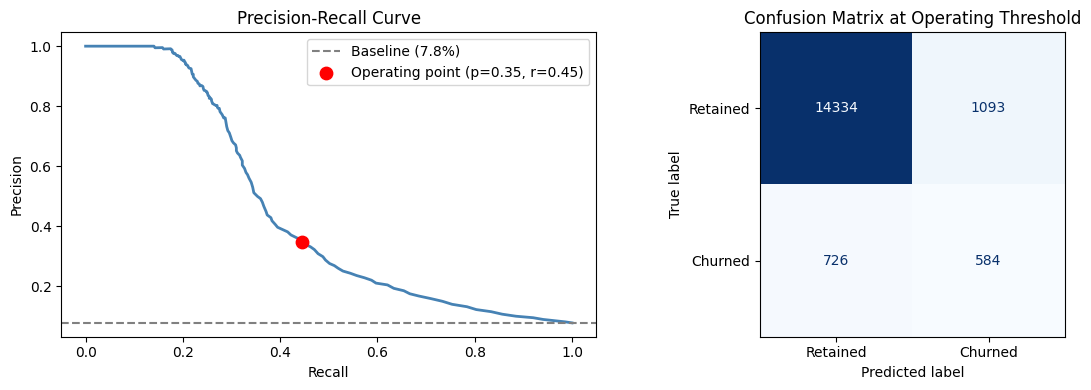


At threshold 0.165:
  Of every 10 interventions → ~3 will be genuine churners


In [169]:
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y, oof_probs)
op_thresh = np.quantile(oof_probs, 0.90)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(recall, precision, color="steelblue", lw=2)
axes[0].axhline(y.mean(), color="gray", linestyle="--", label=f"Baseline ({y.mean():.1%})")
idx = np.argmin(np.abs(thresholds - op_thresh))
axes[0].scatter(recall[idx], precision[idx], color="red", s=80, zorder=5,
                label=f"Operating point (p={precision[idx]:.2f}, r={recall[idx]:.2f})")
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].legend()

y_pred = (oof_probs >= op_thresh).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y, y_pred),
    display_labels=["Retained","Churned"]).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix at Operating Threshold")
plt.tight_layout(); plt.show()

print(f"\nAt threshold {op_thresh:.3f}:")
print(f"  Of every 10 interventions → ~{precision[idx]*10:.0f} will be genuine churners")

In [176]:
for col in ["last_active_month", "recency", "segment", "segment_name",
            "retention_action", "retention_offer",
            "retention_timing", "retention_channel", "retention_rationale"]:
    if col in master.columns:
        master.drop(columns=col, inplace=True)

In [177]:
# ============================================================
# COMPLETE SEGMENTATION + RETENTION PIPELINE
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# ── STEP 1: BUILD RFM FEATURES ─────────────────────────────
last_active = (
    activity_2017[activity_2017["Total Flights"] > 0]
    .groupby("Loyalty Number")["Month"]
    .max()
    .reset_index()
    .rename(columns={"Month": "last_active_month"})
)

master = master.merge(last_active, on="Loyalty Number", how="left")
master["recency"] = (12 - master["last_active_month"]).fillna(12)

rfm_features = ["recency", "total_flights_2017", "CLV", "redemption_rate"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(master[rfm_features])

# ── STEP 2: FIT KMEANS (k=4) ────────────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
master["segment"] = km_final.fit_predict(rfm_scaled)

# ── NAME SEGMENTS FROM PROFILE CHARACTERISTICS, NOT INTEGER IDs ──
# KMeans cluster IDs (0,1,2,3) are arbitrary — they change between runs.
# Instead, we read the actual profile of each cluster and assign names
# based on what the data shows, not which number the cluster got.

profile = master.groupby("segment").agg(
    clv     = ("CLV", "mean"),
    flights = ("total_flights_2017", "mean"),
    recency = ("recency", "mean"),   # higher = more dormant
).round(2)

print("Raw cluster profiles (before naming):")
print(profile.to_string())

name_map = {}

# Rule 1: Highest average CLV → Premium Loyalists
name_map[profile["clv"].idxmax()] = "Premium Loyalists"

# Rule 2: Highest recency (most months since last flight) → Dormant Members
name_map[profile["recency"].idxmax()] = "Dormant Members"

# Rules 3 & 4: From the two remaining clusters,
# more flights → Frequent Flyers, fewer flights → Active Engagers
remaining = [i for i in profile.index if i not in name_map]
sub = profile.loc[remaining]
name_map[sub["flights"].idxmax()] = "Frequent Flyers"
name_map[sub["flights"].idxmin()] = "Active Engagers"

print(f"\nSegment mapping: {name_map}")
master["segment_name"] = master["segment"].map(name_map)
print(f"\nFinal counts:\n{master['segment_name'].value_counts().to_string()}")

# ── STEP 4: RETENTION RULES ─────────────────────────────────
retention_rules = {

    ("Premium Loyalists", "High"): {
        "action"   : "Personal loyalty ambassador call",
        "timing"   : "Within 7 days",
        "offer"    : "Complimentary upgrade + 2x points for 60 days",
        "channel"  : "Phone call from loyalty team",
        "rationale": "Highest CLV group ($27k avg) — losing one costs more than any intervention"
    },
    ("Premium Loyalists", "Medium"): {
        "action"   : "Priority re-engagement email",
        "timing"   : "Within 14 days",
        "offer"    : "1.5x points on next 3 flights",
        "channel"  : "Personalised email",
        "rationale": "Early warning on highest value segment — act before risk escalates"
    },
    ("Premium Loyalists", "Low"): {
        "action"   : "Quarterly VIP reward",
        "timing"   : "End of each quarter",
        "offer"    : "Surprise bonus points based on quarterly activity",
        "channel"  : "Email + app notification",
        "rationale": "Maintain loyalty — these members drive disproportionate revenue"
    },

    ("Active Engagers", "High"): {
        "action"   : "Redemption incentive campaign",
        "timing"   : "Within 14 days",
        "offer"    : "Double value on next points redemption",
        "channel"  : "Email + app push",
        "rationale": "High redemption rate means points are their hook — use it"
    },
    ("Active Engagers", "Medium"): {
        "action"   : "Engagement check-in email",
        "timing"   : "Within 21 days",
        "offer"    : "1.5x points on next flight",
        "channel"  : "Email",
        "rationale": "Recently active and engaged — small nudge enough to retain"
    },
    ("Active Engagers", "Low"): {
        "action"   : "Routine loyalty communication",
        "timing"   : "Monthly newsletter",
        "offer"    : "Programme updates and upcoming promotions",
        "channel"  : "Email",
        "rationale": "Healthy segment — maintain with low-cost touchpoints"
    },

    ("Frequent Flyers", "High"): {
        "action"   : "Tier upgrade fast-track",
        "timing"   : "Within 14 days",
        "offer"    : "Fast-track to next loyalty tier if 3 flights booked in 60 days",
        "channel"  : "Email + app push notification",
        "rationale": "Frequent flyers respond to status — tier upgrade locks in behaviour"
    },
    ("Frequent Flyers", "Medium"): {
        "action"   : "Points expiry warning",
        "timing"   : "60 days before points expire",
        "offer"    : "Reminder of points balance + redemption options",
        "channel"  : "Email",
        "rationale": "Low redemption rate — nudging redemption drives re-engagement"
    },
    ("Frequent Flyers", "Low"): {
        "action"   : "No intervention — monitor",
        "timing"   : "Review quarterly",
        "offer"    : "None",
        "channel"  : "None",
        "rationale": "Low risk frequent flyers — save budget for higher risk segments"
    },

    ("Dormant Members", "High"): {
        "action"   : "Last-chance win-back",
        "timing"   : "Immediately",
        "offer"    : "50% discount on any flight booked within 14 days",
        "channel"  : "Email + SMS",
        "rationale": "Already inactive and high risk — aggressive offer or accept loss"
    },
    ("Dormant Members", "Medium"): {
        "action"   : "Low-cost reactivation nudge",
        "timing"   : "Within 30 days",
        "offer"    : "500 bonus points for logging in and browsing offers",
        "channel"  : "Email",
        "rationale": "Test engagement cheaply before committing larger budget"
    },
    ("Dormant Members", "Low"): {
        "action"   : "No intervention",
        "timing"   : "None",
        "offer"    : "None",
        "channel"  : "None",
        "rationale": "Dormant but low risk — not worth retention spend"
    },
}

# ── STEP 5: ATTACH ACTIONS TO MASTER ───────────────────────
def get_field(row, field):
    key = (row["segment_name"], str(row["churn_risk_tier"]))
    return retention_rules.get(key, {}).get(field, "No action defined")

master["retention_action"]   = master.apply(lambda r: get_field(r, "action"),    axis=1)
master["retention_offer"]    = master.apply(lambda r: get_field(r, "offer"),     axis=1)
master["retention_timing"]   = master.apply(lambda r: get_field(r, "timing"),    axis=1)
master["retention_channel"]  = master.apply(lambda r: get_field(r, "channel"),   axis=1)
master["retention_rationale"]= master.apply(lambda r: get_field(r, "rationale"), axis=1)

# ── STEP 6: SUMMARY TABLE ───────────────────────────────────
summary = (
    master.groupby(["segment_name", "churn_risk_tier"])
    .agg(
        members        = ("Loyalty Number", "count"),
        avg_clv        = ("CLV", "mean"),
        avg_churn_prob = ("churn_probability", "mean"),
        retention_action = ("retention_action", "first"),
        retention_offer  = ("retention_offer",  "first"),
        retention_timing = ("retention_timing",  "first"),
        retention_channel= ("retention_channel", "first"),
    )
    .round(2)
    .reset_index()
)

print("RETENTION ACTION SUMMARY")
print("=" * 80)
for _, row in summary.iterrows():
    print(f"\n{row['segment_name']} — {row['churn_risk_tier']} Risk")
    print(f"  Members        : {row['members']}")
    print(f"  Avg CLV        : ${row['avg_clv']:,.0f}")
    print(f"  Avg Churn Prob : {row['avg_churn_prob']:.1%}")
    print(f"  Action         : {row['retention_action']}")
    print(f"  Offer          : {row['retention_offer']}")
    print(f"  Timing         : {row['retention_timing']}")
    print(f"  Channel        : {row['retention_channel']}")

# ── STEP 7: EXPORT ──────────────────────────────────────────
urgent = (
    master[master["churn_risk_tier"] == "High"][[
        "Loyalty Number", "segment_name", "churn_probability",
        "CLV", "retention_action", "retention_offer",
        "retention_timing", "retention_channel"
    ]]
    .sort_values("churn_probability", ascending=False)
)

master[[
    "Loyalty Number", "segment_name", "churn_risk_tier",
    "churn_probability", "CLV", "retention_action",
    "retention_offer", "retention_timing", "retention_channel"
]].to_csv("retention_actions_all.csv", index=False)

urgent.to_csv("retention_actions_urgent.csv", index=False)

print(f"\nHigh-risk members flagged for immediate action : {len(urgent)}")
print(f"Exported: retention_actions_all.csv")
print(f"Exported: retention_actions_urgent.csv")

Raw cluster profiles (before naming):
              clv  flights  recency
segment                            
0         6638.13    13.50     1.05
1         7040.83     0.21    11.85
2         6380.08    18.88     0.68
3        27729.03    15.43     2.56

Segment mapping: {np.int32(3): 'Premium Loyalists', np.int32(1): 'Dormant Members', np.int32(2): 'Frequent Flyers', np.int32(0): 'Active Engagers'}

Final counts:
segment_name
Frequent Flyers      9755
Dormant Members      4309
Active Engagers      1564
Premium Loyalists    1109


/tmp/ipykernel_2889/3513071507.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  master.groupby(["segment_name", "churn_risk_tier"])


RETENTION ACTION SUMMARY

Active Engagers — Low Risk
  Members        : 934
  Avg CLV        : $6,689
  Avg Churn Prob : 3.0%
  Action         : Routine loyalty communication
  Offer          : Programme updates and upcoming promotions
  Timing         : Monthly newsletter
  Channel        : Email

Active Engagers — Medium Risk
  Members        : 400
  Avg CLV        : $6,414
  Avg Churn Prob : 11.0%
  Action         : Engagement check-in email
  Offer          : 1.5x points on next flight
  Timing         : Within 21 days
  Channel        : Email

Active Engagers — High Risk
  Members        : 230
  Avg CLV        : $6,820
  Avg Churn Prob : 31.0%
  Action         : Redemption incentive campaign
  Offer          : Double value on next points redemption
  Timing         : Within 14 days
  Channel        : Email + app push

Dormant Members — Low Risk
  Members        : 2903
  Avg CLV        : $6,943
  Avg Churn Prob : 2.0%
  Action         : No intervention
  Offer          : None
  Tim